# Walk Forward Validation Analysis and Model Selection
In this notebook, we explore the results of the walk-forward validation experiment, portfolio performances. Eventually, these are used to selected models that will be passed on to the testing stage on completely unseen data with no look ahead bias.

### Setup:

In [1]:
# All imports
import sys
from pathlib import Path

# Get the absolute path of the directory one level up
root_dir = Path.cwd().parent

# Add it to sys.path if it's not already there
if str(root_dir) not in sys.path:
    sys.path.append(str(root_dir))

import os
import numpy as np
import pandas as pd
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import plotly.graph_objects as go
from src.utils.io import load_path_config
from src.data_processing.loading import load_csv_files, ArtifactDataExtractor
from src.evaluation.evaluator import filter_models
from sklearn.decomposition import PCA
from src.utils.window import calc_current_idxs, get_date_index_col
from sklearn.preprocessing import StandardScaler
from src.visualization.plots import plot_windowed_comparison, plot_corr, plot_3d_pareto, plot_2d_pareto
from src.evaluation.selection import high_corr_with_each_metric, pareto_dominance
from src.utils.constants import EQ_WT_NAME, SP500_NAME

from src.models.registry import TradModelLibrary, NNModelLibrary

In [2]:
paths_config = load_path_config(os.path.join('../config', 'paths.json'))

# Convert str paths to Path
artifacts_paths = {}
for name, path in paths_config['artifacts'].items():
    dir_path = Path('../'+ path)
    artifacts_paths[name] = dir_path

TradModelLibrary.autodiscover('src.models')
# Registering all NN models to the library
NNModelLibrary.autodiscover('src.models') # MUST be executed for model registration

In [3]:

grid_mode = 'one_model'
model_name = None
loss_name = None # Change previous grid mode if needed

extractor = ArtifactDataExtractor(grid_mode, artifacts_paths)

if grid_mode == 'one_model':
    # Get all models from library
    all_models = []
    for cat in NNModelLibrary.list_categories():
        all_models.extend(NNModelLibrary.list_models(cat))

    all_avg_perf = extractor.agg_avg_perf('avg_perf', all_models)
    opti_hparams = extractor.agg_opti_hparams('optimized', all_models)
    all_daily_rets = extractor.agg_daily_rets('daily_rets', all_models)

    #### Remove custom losses 13 and 14 ####
    # mask = all_avg_perf.index.str.contains('-custom_loss_13|-custom_loss_14')
    # all_avg_perf = all_avg_perf[~mask]
    
elif grid_mode == 'one' and model_name is not None and loss_name is not None:
    opti_hparams = extractor.agg_opti_hparams(
        'optimized', [f'{model_name}-{loss_name}']
    )
    filtered_models = None

AVG_PERF file for DeformTime not found at DeformTime. Skipping!
OPTIMIZED file for DeformTime not found at DeformTime. Skipping!
DAILY_RETS file for DeformTime not found at DeformTime. Skipping!
DAILY_RETS file for TemporalTransformer not found at TemporalTransformer. Skipping!
DAILY_RETS file for PatchTST not found at PatchTST. Skipping!
DAILY_RETS file for BaseLSTM not found at BaseLSTM. Skipping!
DAILY_RETS file for AttentionLSTM not found at AttentionLSTM. Skipping!
DAILY_RETS file for InvertedAttentionLSTM not found at InvertedAttentionLSTM. Skipping!
DAILY_RETS file for VLSTM not found at VLSTM. Skipping!


In [4]:
# all_benches = TradModelLibrary.list_models()
all_benches = [EQ_WT_NAME, SP500_NAME]

# Filter models that beat Equal Weight Portfolio
filtered_perf, filtered_models = filter_models(
    all_avg_perf, EQ_WT_NAME, 'sharpe', all_benches
)

print(f'\n {len(filtered_models)} Models beat Equal Weight portfolio.')
# print('Filtered Avg. Performance Metrics: \n', filtered_perf)
filtered_perf = filtered_perf.sort_values(by='sharpe', ascending=False)
filtered_perf


 16 Models beat Equal Weight portfolio.


,compunded_return,sharpe,sortino,max_drawdown,cvar,omega,calmar
AttentionLSTM-custom_loss_10,0.124800,0.121213,0.202425,-0.144175,-0.044050,1.442350,0.033450
TemporalTransformer-custom_loss_11,0.096713,0.120262,0.206937,-0.107100,-0.034050,1.383037,0.024625
PatchTST-custom_loss_12,0.132513,0.118813,0.198150,-0.125487,-0.043550,1.435712,0.032275
InvertedAttentionLSTM-custom_loss_13,0.063850,0.114025,0.170100,-0.097988,-0.032975,1.393500,0.023400
TemporalTransformer-custom_loss_13,0.076063,0.112712,0.170075,-0.092875,-0.031238,1.379775,0.022638
PatchTST-custom_loss_13,0.094462,0.111662,0.190013,-0.118962,-0.037575,1.368263,0.026625
InvertedAttentionLSTM-custom_loss_10,0.080863,0.111250,0.162038,-0.096138,-0.034200,1.378388,0.023438
AttentionLSTM-custom_loss_12,0.082263,0.110175,0.173538,-0.125850,-0.040612,1.378400,0.023338
VLSTM-custom_loss_13,0.070087,0.109987,0.171287,-0.095025,-0.031738,1.371750,0.022250
PatchTST-custom_loss_14,0.059100,0.109750,0.165600,-0.095500,-0.031700,1.377700,0.022900


In [5]:
all_avg_perf

,compunded_return,sharpe,sortino,max_drawdown,cvar,omega,calmar
TemporalTransformer-custom_loss_6,0.055175,0.104838,0.152362,-0.099425,-0.034225,1.350763,0.021112
TemporalTransformer-custom_loss_10,0.111350,0.066325,0.113400,-0.168650,-0.054175,1.236163,0.016588
TemporalTransformer-custom_loss_11,0.096713,0.120262,0.206937,-0.107100,-0.034050,1.383037,0.024625
TemporalTransformer-custom_loss_12,0.057250,0.106762,0.163400,-0.095900,-0.031700,1.374100,0.022400
TemporalTransformer-custom_loss_13,0.076063,0.112712,0.170075,-0.092875,-0.031238,1.379775,0.022638
TemporalTransformer-custom_loss_14,0.074825,0.107775,0.166662,-0.089275,-0.029937,1.362925,0.022225
Equal_Weight,0.056287,0.107725,0.163887,-0.095925,-0.031587,1.374600,0.022575
S&P500,0.049075,0.104487,0.139950,-0.092262,-0.032350,1.343400,0.020125
PatchTST-custom_loss_6,0.082950,0.081337,0.165837,-0.174787,-0.061337,1.264050,0.020350
PatchTST-custom_loss_10,0.052262,0.088887,0.131988,-0.115900,-0.037112,1.295587,0.017500


## Mean Sharpe Analysis
### Overall View

Models/Approaches that BEAT Equal Weight Mean Sharpe:


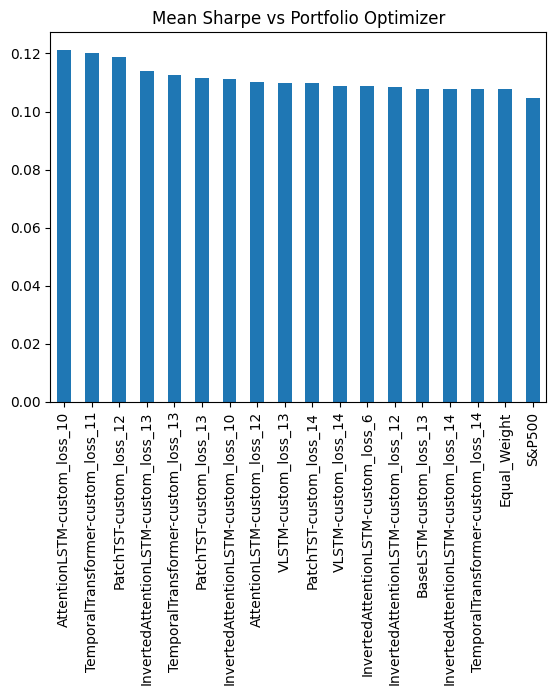

In [6]:

filtered_perf['sharpe'].plot.bar(title='Mean Sharpe vs Portfolio Optimizer')
print('Models/Approaches that BEAT Equal Weight Mean Sharpe:')

In [7]:
print('Models/Approaches that DID NOT BEAT Equal Weight Mean Sharpe:')
no_beat = all_avg_perf.drop(filtered_perf.index, axis=0)
print(f'{len(no_beat)} NN models did not beat Equal Weight Portfolio:')
no_beat

Models/Approaches that DID NOT BEAT Equal Weight Mean Sharpe:
20 NN models did not beat Equal Weight Portfolio:


,compunded_return,sharpe,sortino,max_drawdown,cvar,omega,calmar
TemporalTransformer-custom_loss_6,0.055175,0.104838,0.152362,-0.099425,-0.034225,1.350763,0.021112
TemporalTransformer-custom_loss_10,0.111350,0.066325,0.113400,-0.168650,-0.054175,1.236163,0.016588
TemporalTransformer-custom_loss_12,0.057250,0.106762,0.163400,-0.095900,-0.031700,1.374100,0.022400
PatchTST-custom_loss_6,0.082950,0.081337,0.165837,-0.174787,-0.061337,1.264050,0.020350
PatchTST-custom_loss_10,0.052262,0.088887,0.131988,-0.115900,-0.037112,1.295587,0.017500
PatchTST-custom_loss_11,0.077475,0.080138,0.143712,-0.129550,-0.039412,1.268750,0.021763
BaseLSTM-custom_loss_6,0.078487,0.088225,0.151700,-0.110900,-0.036975,1.305375,0.021862
BaseLSTM-custom_loss_10,0.066912,0.095687,0.147863,-0.111338,-0.037012,1.326437,0.020237
BaseLSTM-custom_loss_11,0.051825,0.079450,0.116175,-0.126325,-0.038375,1.242538,0.015125
BaseLSTM-custom_loss_12,0.054337,0.096388,0.139838,-0.102750,-0.033500,1.313125,0.017900


In [8]:
# Split Benchmarks and filtered models

benchmarks_df = all_avg_perf[all_avg_perf.index.isin(all_benches)]
all_avg_perf = all_avg_perf[~all_avg_perf.index.isin(all_benches)]

## Multi Metric Analysis:

### Correlation Analysis

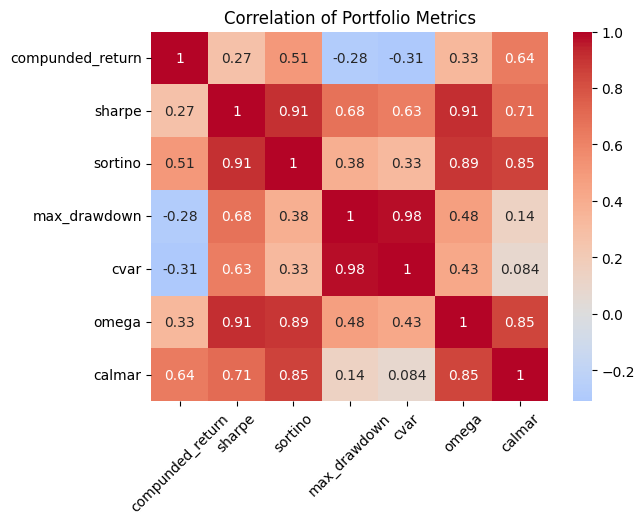


sharpe is highly correlated with:
  sortino: 0.907
  omega: 0.915

sortino is highly correlated with:
  sharpe: 0.907
  omega: 0.893
  calmar: 0.853

max_drawdown is highly correlated with:
  cvar: 0.977

cvar is highly correlated with:
  max_drawdown: 0.977

omega is highly correlated with:
  sharpe: 0.915
  sortino: 0.893
  calmar: 0.846

calmar is highly correlated with:
  sortino: 0.853
  omega: 0.846


In [9]:
corr = all_avg_perf.corr()

plot_corr(corr, title='Correlation of Portfolio Metrics')

high_corr_with_each_metric(corr, threshold=0.75)

Most metrics are highly correlated with each other, with omega and sharpe showing high correlation with most of the other metrics. We can choose Sharpe, Calmar and maybe even CVaR to be our main metrics. CVaR and MDD are highly correlated so we can have one of them to add in loss like or bad scenarios.

##### Principle Component Analysis:

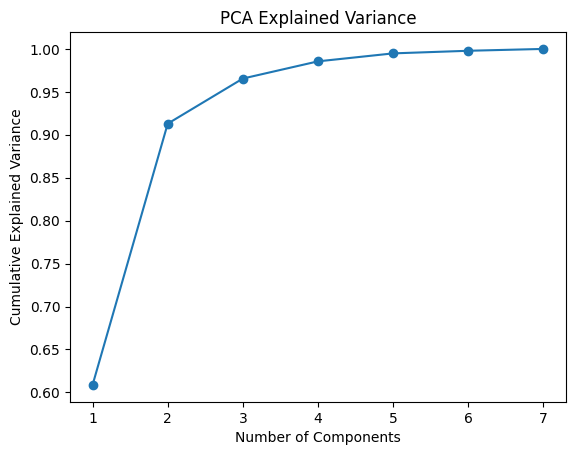

In [10]:
scaler = StandardScaler()
scaled_perf = scaler.fit_transform(all_avg_perf)

pca = PCA()
pca.fit(scaled_perf)

# Explained variance ratio
explained = pca.explained_variance_ratio_
cumulative = explained.cumsum()

plt.plot(range(1, len(explained)+1), cumulative, 'o-')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance')
plt.show()

The first principle component explains ~ 25% of the variance. At 6 princple components, almost 100% of the variance is explained.

In [11]:
loadings = pca.components_.T 

def print_important_metrics(loadings, metrics, n_components=5, top_n=3):
    for i in range(n_components):
        # Get loadings for component i
        comp_loadings = loadings[:, i]
        # Sort by absolute value
        sorted_idx = np.argsort(np.abs(comp_loadings))[::-1]
        print(f"\nPrincipal Component {i+1} (explained variance: {pca.explained_variance_ratio_[i]:.3f})")
        for j in range(top_n):
            idx = sorted_idx[j]
            print(f"  {metrics[idx]}: {comp_loadings[idx]:.3f}")

# Example:
print_important_metrics(loadings, all_avg_perf.columns, n_components=6, top_n=3)


Principal Component 1 (explained variance: 0.609)
  sharpe: 0.473
  omega: 0.459
  sortino: 0.453

Principal Component 2 (explained variance: 0.304)
  compunded_return: 0.544
  cvar: -0.535
  max_drawdown: -0.514

Principal Component 3 (explained variance: 0.053)
  compunded_return: 0.782
  omega: -0.393
  cvar: 0.329

Principal Component 4 (explained variance: 0.020)
  calmar: 0.665
  sortino: -0.552
  sharpe: -0.407

Principal Component 5 (explained variance: 0.009)
  omega: 0.664
  sortino: -0.514
  calmar: -0.430

Principal Component 6 (explained variance: 0.003)
  cvar: 0.693
  max_drawdown: -0.663
  sharpe: -0.196


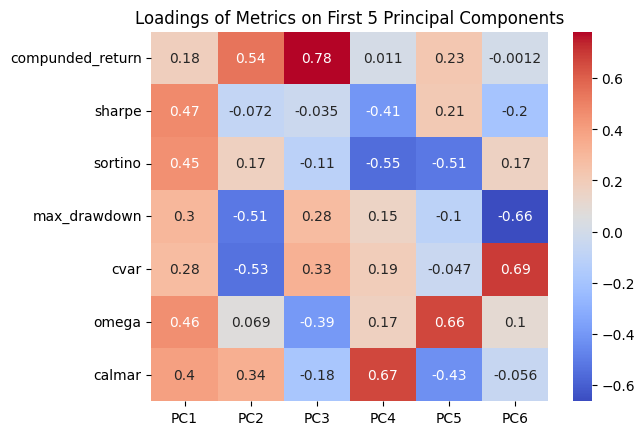

In [12]:
plt.figure()
sns.heatmap(loadings[:, :6], annot=True, cmap='coolwarm', 
            xticklabels=[f'PC{i+1}' for i in range(6)],
            yticklabels=all_avg_perf.columns)
plt.title('Loadings of Metrics on First 5 Principal Components')
plt.show()

PC1 (explains 50.0% of variance) – High positive loadings on Sharpe (0.50), Omega (0.48), and Sortino (0.48).
- PC1 captures risk‑adjusted return (higher is better).
PC2 (explains 27.8% of variance) – High positive loading on CVaR (0.58) (which is undesirable) and negative loadings on Calmar (–0.46) and compounded return (–0.46) (both desirable).
- Higher PC2 indicates higher tail risk, lower drawdown‑adjusted return, and lower raw return – i.e., worse overall.
- To align with “higher is better”, we invert PC2 (use –PC2). Then –PC2 represents low tail risk, high Calmar, and high raw return.
PC3 (explains 12.9% of variance) – High positive loading on compounded return (0.76) but also positive on CVaR (0.33) and negative on Calmar (–0.48). This component is ambiguous (higher raw return comes with higher tail risk and lower Calmar), so we do not use it for Pareto selection.
Thus, we construct a 2D Pareto frontier using PC1 (risk‑adjusted return) and –PC2 (low tail risk + high Calmar/return). Both dimensions are “higher is better”, providing a clear, interpretable trade‑off. This approach leverages the PCA results while avoiding the complexity of a third dimension.

For robustness, we also consider the original metrics Sharpe (primary), Calmar (drawdown control), and CVaR (tail risk) as a sanity check. However, the PC1 + –PC2 combination already captures the same information in a more balanced way.

##### Pareto Frontier with Top 2 Principle Components

In [16]:
# Transform the standardized data (already filtered to models only, no benchmarks)
pca_scores = pca.transform(scaled_perf)   # shape (n_models, n_components)

pc_df = pd.DataFrame({
    'PC1': pca_scores[:, 0],
    'PC2_inv': -pca_scores[:, 1]          # invert so higher is better
}, index=all_avg_perf.index)

In [ ]:
# def is_dominated(row, df):
#     for _, other in df.iterrows():
#         if (other['PC1'] >= row['PC1'] and other['PC2_inv'] >= row['PC2_inv'] and
#             (other['PC1'] > row['PC1'] or other['PC2_inv'] > row['PC2_inv'])):
#             return True
#     return False


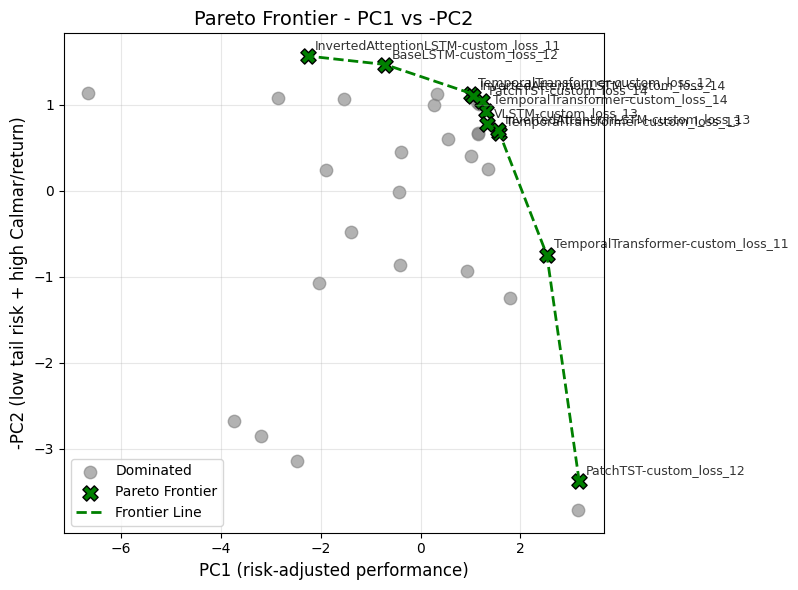

,PC1,PC2_inv,dominated
TemporalTransformer-custom_loss_11,2.530721,-0.746687,False
TemporalTransformer-custom_loss_12,1.016857,1.129544,False
TemporalTransformer-custom_loss_13,1.579800,0.672431,False
TemporalTransformer-custom_loss_14,1.306388,0.925363,False
PatchTST-custom_loss_12,3.178477,-3.375128,False
PatchTST-custom_loss_14,1.229043,1.042887,False
BaseLSTM-custom_loss_12,-0.711206,1.466469,False
InvertedAttentionLSTM-custom_loss_11,-2.258794,1.564902,False
InvertedAttentionLSTM-custom_loss_13,1.550032,0.704532,False
InvertedAttentionLSTM-custom_loss_14,1.050677,1.106320,False


In [ ]:
pc_df['dominated'] = pareto_dominance(pc_df, ['PC1', 'PC2_inv'])
frontier = pc_df[~pc_df['dominated']].copy()

frontier_sorted = frontier.sort_values('PC1')

fig = plot_2d_pareto(
    df=pc_df,
    x_col='PC1',
    y_col='PC2_inv',
    dominated_col='dominated',
    title='Pareto Frontier - PC1 vs -PC2',
    xlabel='PC1 (risk-adjusted performance)',
    ylabel='-PC2 (low tail risk + high Calmar/return)'
)
plt.show()
frontier

In [30]:
fig = px.scatter_3d(
    all_avg_perf,
    x='sharpe',
    y='compunded_return',
    z='cvar',
    hover_name=all_avg_perf.index,
    color='sharpe',                # color by Sharpe (or any metric)
    title='3D Pareto Frontier: Sharpe, Calmar, CVaR',
    labels={
        'sharpe': 'Sharpe Ratio',
        'compunded_return': 'Compunded Return',
        'cvar': 'CVaR (higher better)'
    }
)

# Update marker size and appearance
fig.update_traces(marker=dict(size=5, line=dict(width=1, color='DarkSlateGrey')))

# Optional: add a plane or highlight the Pareto frontier (more complex)
# For simplicity, just show the points.

fig.show()

In [ ]:
temp_avg_perf = all_avg_perf.copy()

cols = ['sharpe', 'compunded_return', 'cvar']
temp_avg_perf['dominated_3d'] = pareto_dominance(temp_avg_perf, cols)

frontier_3d = temp_avg_perf[~temp_avg_perf['dominated_3d']]

fig = plot_3d_pareto(
    df=temp_avg_perf,
    x_col='sharpe',
    y_col='compunded_return',
    z_col='cvar',
    dominated_col='dominated_3d',
    title='3D Pareto Frontier Lower Confidence Bound (Sharpe, Compounded Return, CVaR)',
    x_title='Sharpe Ratio',
    y_title='Compounded Return',
    z_title='CVaR (higher better)'
)

fig.show()

# Efficient frontier models vs Benchmarks
frontier_model_names = list(frontier_3d.index)
pd.concat([frontier_3d, benchmarks_df], axis=0)

,compunded_return,sharpe,sortino,max_drawdown,cvar,omega,calmar,dominated_3d
TemporalTransformer-custom_loss_11,0.096713,0.120262,0.206937,-0.107100,-0.034050,1.383037,0.024625,False
TemporalTransformer-custom_loss_13,0.076063,0.112712,0.170075,-0.092875,-0.031238,1.379775,0.022638,False
TemporalTransformer-custom_loss_14,0.074825,0.107775,0.166662,-0.089275,-0.029937,1.362925,0.022225,False
PatchTST-custom_loss_12,0.132513,0.118813,0.198150,-0.125487,-0.043550,1.435712,0.032275,False
AttentionLSTM-custom_loss_10,0.124800,0.121213,0.202425,-0.144175,-0.044050,1.442350,0.033450,False
InvertedAttentionLSTM-custom_loss_13,0.063850,0.114025,0.170100,-0.097988,-0.032975,1.393500,0.023400,False
Equal_Weight,0.056287,0.107725,0.163887,-0.095925,-0.031587,1.374600,0.022575,NaN
S&P500,0.049075,0.104487,0.139950,-0.092262,-0.032350,1.343400,0.020125,NaN


#### Daily Returns for the frontier models

In [45]:
processed_files = {
    'returns_val': Path(paths_config['processed_paths']['returns_val'])
}

processed_dfs = load_csv_files(processed_files, index_dt=True)

def extract_window_dates(returns_val, num_steps, out_size):
    out_wind_idxs = []
    for step in range(1, num_steps+1):
        current_start, current_end = calc_current_idxs(step, out_size)

        out_wind_idxs.append((current_start, current_end))
    
    out_win_date_cols = get_date_index_col(returns_val, out_wind_idxs)

    return out_win_date_cols


out_win_date_cols = extract_window_dates(processed_dfs['returns_val'], 8, 60)

In [46]:
if all_daily_rets:    
    frontier_daily_rets = {
        k: all_daily_rets[k] for k in frontier_model_names if k in frontier_model_names
    }

    for bench in all_benches:
        bench_rets = all_daily_rets.get(bench)
        if bench_rets:
            frontier_daily_rets.update({bench: bench_rets})

    plot_windowed_comparison(
        all_daily_returns=frontier_daily_rets,
        window_dates=out_win_date_cols,
        windows_per_row=2,
        plot=True
    )
else:
    print('WARNING: No daily returns found.')

#### Training Loss Curves for best performing model loss combination

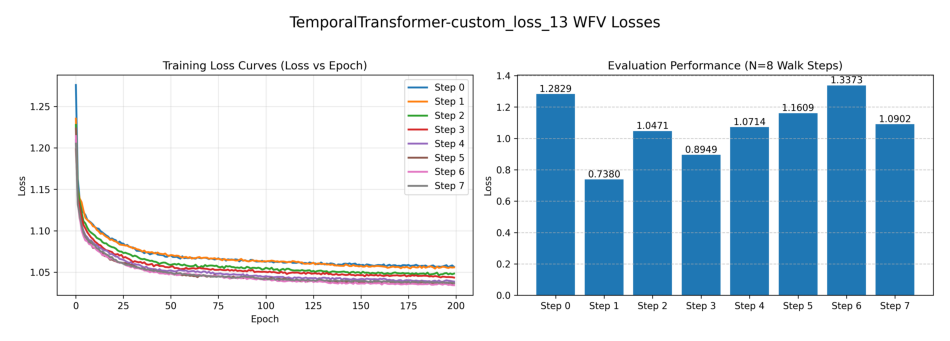

In [52]:
plt.figure(figsize=(12, 8))
img = mpimg.imread(artifacts_paths['tuned_plots_dir'] / 'TemporalTransformer-custom_loss_13 WFV Losses.png')
plt.imshow(img)
plt.axis('off')  # hide axes
plt.show()